In [1]:
# Crop Recommendation System: Model Training and Analysis

## Project Goal
The objective of this project is to build a machine learning system that recommends the best crop to plant based on environmental factors. This notebook covers the end-to-end process of data analysis, model training, comparison, and selection.

**The key steps are:**
1.  **Exploratory Data Analysis (EDA):** Understand the data through visualizations.
2.  **Data Preprocessing:** Prepare the data for model training.
3.  **Model Training & Comparison:** Train four different classification algorithms (Logistic Regression, KNN, Decision Tree, Random Forest) and compare their performance.
4.  **Model Selection:** Automatically choose the best model based on accuracy.
5.  **Save Artifacts:** Save the best model and the data scaler for use in the Flask web application.

SyntaxError: invalid syntax (79983571.py, line 4)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('Crop_recommendation.csv')
print("First 5 rows of the dataset:")
display(df.head())

print("Dataset Information:")
df.info()

First 5 rows of the dataset:


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


Saved crop distribution plot to static/plots\crop_distribution.png


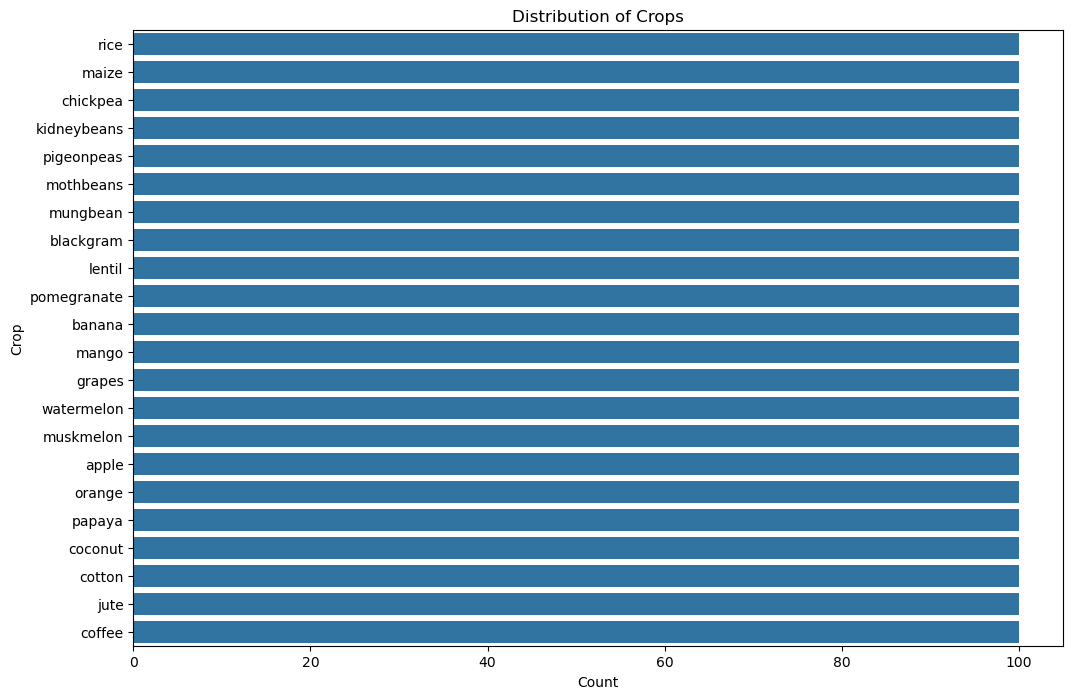

Saved correlation heatmap to static/plots\correlation_heatmap.png


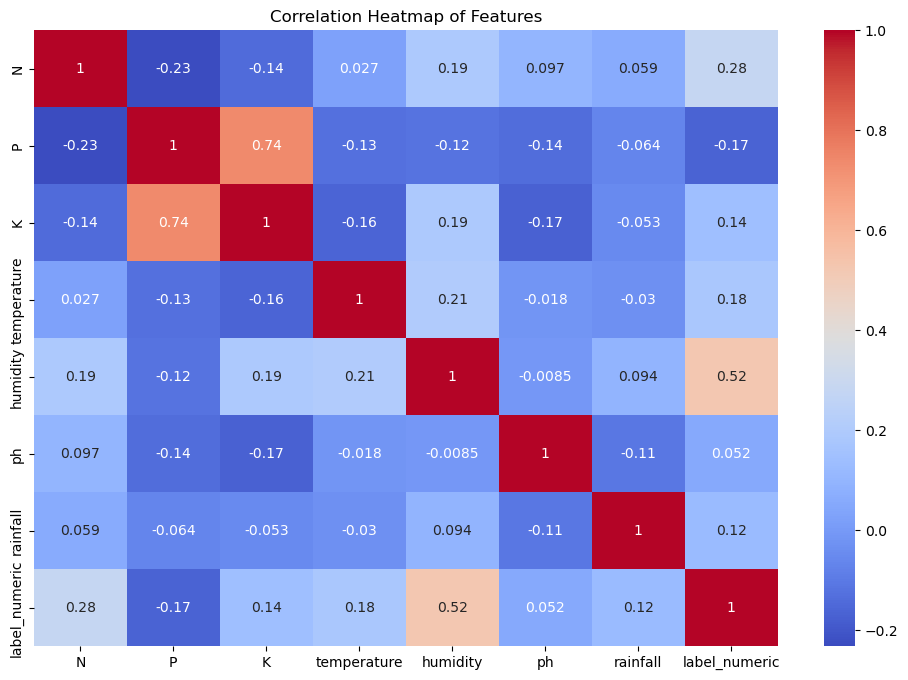

In [3]:
# Create a directory for plots if it doesn't exist
plots_dir = 'static/plots'
if not os.path.exists(plots_dir):
    os.makedirs(plots_dir)

# --- Plot 1: Crop Distribution ---
plt.figure(figsize=(12, 8))

sns.countplot(y=df['label'])
plt.title('Distribution of Crops')
plt.xlabel('Count')
plt.ylabel('Crop')
plt.savefig(os.path.join(plots_dir, 'crop_distribution.png'), bbox_inches='tight')
print(f"Saved crop distribution plot to {os.path.join(plots_dir, 'crop_distribution.png')}")
plt.show()

# --- Plot 2: Correlation Heatmap ---
# We need to convert the 'label' to a numeric format for correlation calculation
temp_df = df.copy()
temp_df['label_numeric'] = pd.factorize(temp_df['label'])[0]

numeric_df = temp_df.drop('label', axis=1)

plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Features')
plt.savefig(os.path.join(plots_dir, 'correlation_heatmap.png'))
print(f"Saved correlation heatmap to {os.path.join(plots_dir, 'correlation_heatmap.png')}")
plt.show()

In [4]:

X = df.drop('label', axis=1)
y = df['label']

# Split data into training and testing sets
# We use stratify=y to ensure the distribution of crops is the same in train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale the features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data preprocessing complete.")
print("X_train shape:", X_train_scaled.shape)
print("X_test shape:", X_test_scaled.shape)

Data preprocessing complete.
X_train shape: (1760, 7)
X_test shape: (440, 7)


Logistic Regression Accuracy: 0.9727
KNN Accuracy: 0.9795
Decision Tree Accuracy: 0.9795
Random Forest Accuracy: 0.9955

Saved model accuracies plot to static/plots\model_accuracies.png


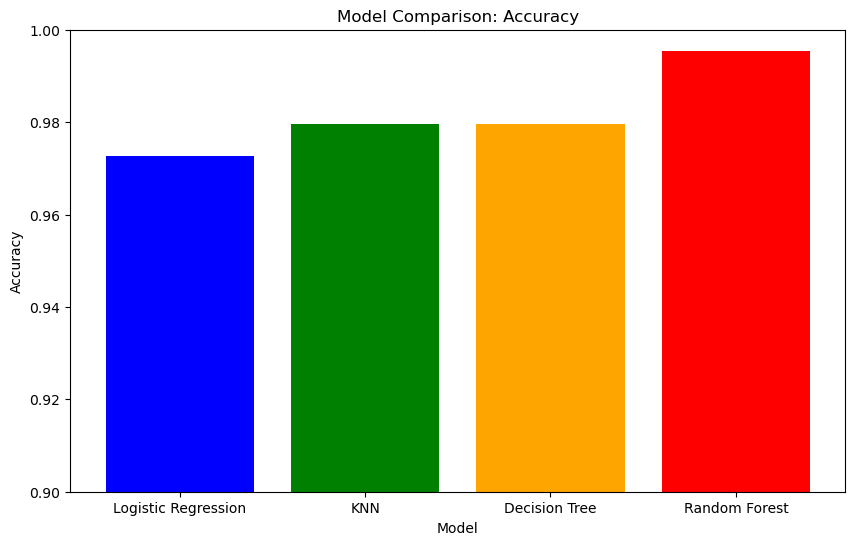

In [9]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

model_accuracies = {}

for name, model in models.items():
    
    model.fit(X_train_scaled, y_train)
    
    
    y_pred = model.predict(X_test_scaled)
    
    
    accuracy = accuracy_score(y_test, y_pred)
    model_accuracies[name] = accuracy
    print(f'{name} Accuracy: {accuracy:.4f}')

# Create a bar chart of model accuracies
plt.figure(figsize=(10, 6))
plt.bar(model_accuracies.keys(), model_accuracies.values(), color=['blue', 'green', 'orange', 'red'])
plt.title('Model Comparison: Accuracy')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0.9, 1.0) # Setting y-axis limit to better visualize differences
plt.savefig(os.path.join(plots_dir, 'model_accuracies.png'))
print(f"\nSaved model accuracies plot to {os.path.join(plots_dir, 'model_accuracies.png')}")
plt.show()

In [10]:
# Find the best model based on accuracy
best_model_name = max(model_accuracies, key=model_accuracies.get)
best_model = models[best_model_name]

print(f'The best model is: "{best_model_name}" with an accuracy of {model_accuracies[best_model_name]:.4f}')

# Save the best model to a .pkl file
with open('crop_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

# Save the scaler to a .pkl file
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print('\nBest model (`crop_model.pkl`) and scaler (`scaler.pkl`) have been saved successfully.')

The best model is: "Random Forest" with an accuracy of 0.9955

Best model (`crop_model.pkl`) and scaler (`scaler.pkl`) have been saved successfully.


Saved feature importance plot to static/plots\feature_importance.png


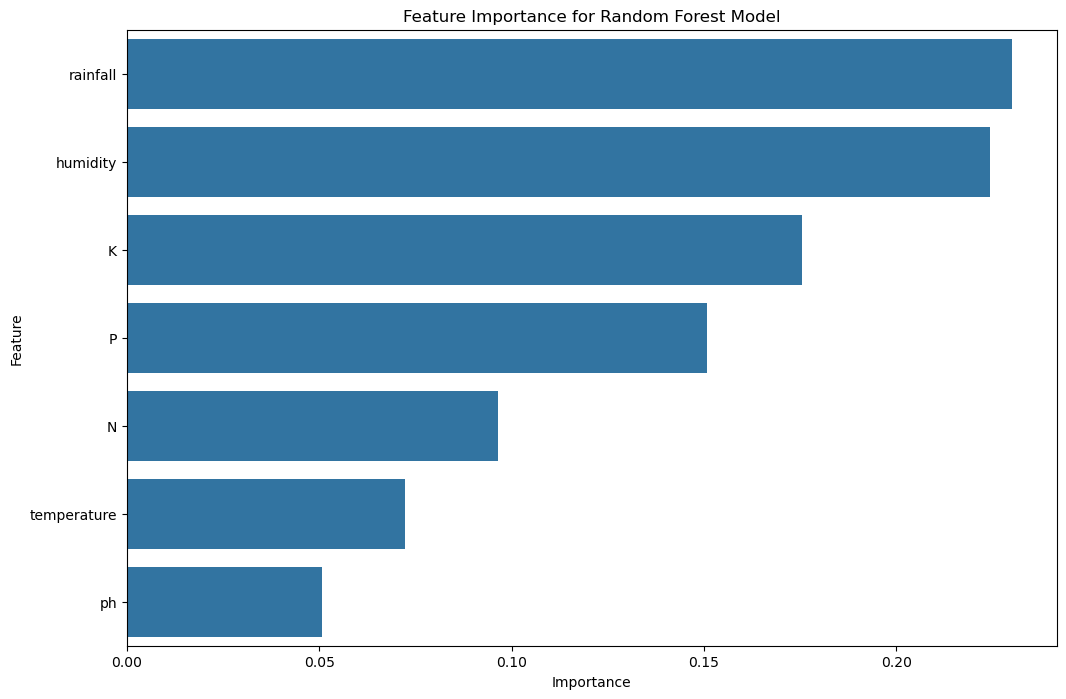

In [11]:
# This cell assumes Random Forest is one of the models.
if 'Random Forest' in models:
    rf_model = models['Random Forest']
    importances = rf_model.feature_importances_
    feature_names = X.columns
    
    # Create a DataFrame for better visualization
    feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
    
    plt.figure(figsize=(12, 8))
    sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
    plt.title('Feature Importance for Random Forest Model')
    plt.savefig(os.path.join(plots_dir, 'feature_importance.png'), bbox_inches='tight')
    print(f"Saved feature importance plot to {os.path.join(plots_dir, 'feature_importance.png')}")
    plt.show()